In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import re

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
})

ALLOWED_LRS = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
_cmap_base = plt.cm.plasma
LR_COLORS = {lr: _cmap_base(i / (len(ALLOWED_LRS) - 1)) for i, lr in enumerate(ALLOWED_LRS)}

def _snap_lr(val, tol=0.01):
    for a in ALLOWED_LRS:
        if a > 0 and abs(val - a) / a < tol:
            return a
    return None

def filter_lr(df, tol=0.01):
    mask = df['lr'].apply(lambda x: any(abs(x - a) / a < tol for a in ALLOWED_LRS if a > 0))
    return df[mask]

In [110]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import re

# # ── ACL camera-ready style ──────────────────────────────────────────────
# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
#     'font.size': 9,
#     'axes.labelsize': 10,
#     'axes.titlesize': 10,
#     'xtick.labelsize': 8,
#     'ytick.labelsize': 8,
#     'legend.fontsize': 7.5,
#     'figure.dpi': 150,
#     'savefig.dpi': 300,
#     'savefig.bbox': 'tight',
#     'savefig.pad_inches': 0.02,
#     'axes.spines.top': False,
#     'axes.spines.right': False,
#     'axes.linewidth': 0.6,
#     'xtick.major.width': 0.6,
#     'ytick.major.width': 0.6,
#     'xtick.major.size': 3,
#     'ytick.major.size': 3,
# })

# # ALLOWED_LRS = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

# # def filter_lr(df, tol=0.01):
# #     mask = df['lr'].apply(lambda x: any(abs(x - a) / a < tol for a in ALLOWED_LRS if a > 0))
# #     return df[mask]

# # ── Size categorization ─────────────────────────────────────────────────
# LORA_RANK_BINS = {1: 'Small', 3: 'Medium', 8: 'Medium', 16: 'Medium', 32: 'Large'}
# UI_SVECS_BINS = [(0, 32, 'Small'), (64, 256, 'Medium'), (512, float('inf'), 'Large')]
# VERA_DEFAULT_SIZE = 'Small'

# SIZE_CATEGORIES = ['Small', 'Medium', 'Large']
# SIZE_COLORS = {
#     'Small':  '#2166ac',   # blue
#     'Medium': '#f4a582',   # salmon
#     'Large':  '#b2182b',   # red
# }
# SIZE_MARKERS = {
#     'Small':  'o',
#     'Medium': 's',
#     'Large':  'D',
# }

# def _get_size_category(row):
#     adapter = row.get('adapter_type', '')
#     if adapter == 'vera':
#         return VERA_DEFAULT_SIZE
#     elif adapter == 'uiortholora':
#         svecs = row.get('svecs', np.nan)
#         if pd.isna(svecs):
#             return 'Small'
#         svecs = float(svecs)
#         for lo, hi, label in UI_SVECS_BINS:
#             if lo <= svecs <= hi:
#                 return label
#         return 'Large'
#     else:  # lora, dora
#         rank = row.get('rank', 0)
#         try:
#             rank = int(float(rank))
#         except (ValueError, TypeError):
#             rank = 0
#         return LORA_RANK_BINS.get(rank, 'Large')


# def plot_adapter_panels_by_size(
#     merged_mmlu, merged_bigbench,
#     model, task,
#     neg_shift_col='negative_shift_score',
#     task_acc_col='accuracy',
#     mmlu_col='mmlu_acc',
#     bigbench_col='mean_accuracy',
#     figsize=(7, 2.4),
#     save_path=None,
#     dpi=300
# ):
#     task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
#     model_label = model.replace('gemma-12b', 'Gemma-2 12B').replace('llama-3b', 'Llama-3.2 3B')

#     adapters_mmlu = set(merged_mmlu['adapter_type'].unique()) if not merged_mmlu.empty else set()
#     adapters_bb   = set(merged_bigbench['adapter_type'].unique()) if not merged_bigbench.empty else set()
#     all_adapters  = sorted(adapters_mmlu | adapters_bb)

#     adapter_display = {
#         'lora': 'LoRA', 'dora': 'DoRA',
#         'uiortholora': 'UIorthoLoRA', 'vera': 'VeRA',
#         'unknown': 'Unknown'
#     }

#     for adapter in all_adapters:
#         display_name = adapter_display.get(adapter, adapter)

#         fig, axes = plt.subplots(
#             1, 3, figsize=figsize,
#             sharey=True,
#             gridspec_kw={'wspace': 0.08}
#         )
#         fig.suptitle(f'{display_name} on {model_label} ({task_label}QA)',
#                      fontsize=11, fontweight='bold', y=1.01)

#         # ── Prepare data subsets ────────────────────────────────────
#         if neg_shift_col in merged_mmlu.columns:
#             src_neg = merged_mmlu
#         elif neg_shift_col in merged_bigbench.columns:
#             src_neg = merged_bigbench
#         else:
#             src_neg = pd.DataFrame()

#         neg_sub = (src_neg[src_neg['adapter_type'] == adapter]
#                    .dropna(subset=[neg_shift_col, task_acc_col, 'lr'])
#                    if not src_neg.empty else pd.DataFrame())
#         mmlu_sub = (merged_mmlu[merged_mmlu['adapter_type'] == adapter]
#                     .dropna(subset=[mmlu_col, task_acc_col, 'lr'])
#                     if not merged_mmlu.empty else pd.DataFrame())
#         bb_sub = (merged_bigbench[merged_bigbench['adapter_type'] == adapter]
#                   .dropna(subset=[bigbench_col, task_acc_col, 'lr'])
#                   if not merged_bigbench.empty else pd.DataFrame())

#         neg_sub  = filter_lr(neg_sub)  if not neg_sub.empty  else neg_sub
#         mmlu_sub = filter_lr(mmlu_sub) if not mmlu_sub.empty else mmlu_sub
#         bb_sub   = filter_lr(bb_sub)   if not bb_sub.empty   else bb_sub

#         # Add size category column
#         for df in [neg_sub, mmlu_sub, bb_sub]:
#             if not df.empty:
#                 df['size_cat'] = df.apply(_get_size_category, axis=1)

#         panel_configs = [
#             {'ax': axes[0], 'data': neg_sub,
#              'x_col': neg_shift_col, 'y_col': task_acc_col,
#              'x_label': 'Negative Shift'},
#             {'ax': axes[1], 'data': mmlu_sub,
#              'x_col': mmlu_col, 'y_col': task_acc_col,
#              'x_label': 'MMLU Accuracy'},
#             {'ax': axes[2], 'data': bb_sub,
#              'x_col': bigbench_col, 'y_col': task_acc_col,
#              'x_label': 'BigBench Accuracy'},
#         ]

#         legend_handles_added = set()

#         for pi, cfg in enumerate(panel_configs):
#             ax   = cfg['ax']
#             data = cfg['data']

#             ax.set_xlabel(cfg['x_label'])
#             ax.grid(True, linestyle='-', linewidth=0.3, alpha=0.35, color='#bbbbbb')

#             if pi == 0:
#                 ax.set_ylabel(f'{task_label}QA Accuracy')

#             if data.empty:
#                 ax.text(0.5, 0.5, 'No data', ha='center', va='center',
#                         transform=ax.transAxes, fontsize=9, color='gray')
#                 continue

#             x  = data[cfg['x_col']].values.astype(float)
#             y  = data[cfg['y_col']].values.astype(float)
#             cats = data['size_cat'].values

#             # Jitter
#             rng = np.random.default_rng(42 + pi)
#             x_range = np.ptp(x) if np.ptp(x) > 0 else 1.0
#             y_range = np.ptp(y) if np.ptp(y) > 0 else 1.0
#             jx = x + rng.uniform(-0.018, 0.018, size=len(x)) * x_range
#             jy = y + rng.uniform(-0.018, 0.018, size=len(y)) * y_range

#             # Plot each size category
#             for cat in SIZE_CATEGORIES:
#                 mask = cats == cat
#                 if not mask.any():
#                     continue
#                 label = cat if cat not in legend_handles_added else None
#                 ax.scatter(
#                     jx[mask], jy[mask],
#                     c=SIZE_COLORS[cat],
#                     marker=SIZE_MARKERS[cat],
#                     s=28, alpha=0.82,
#                     edgecolors='#444444', linewidth=0.25,
#                     zorder=3, label=label, rasterized=True
#                 )
#                 if label:
#                     legend_handles_added.add(cat)

#         # ── Legend ──────────────────────────────────────────────────
#         handles, labels = [], []
#         for cat in SIZE_CATEGORIES:
#             if cat in legend_handles_added:
#                 handles.append(plt.Line2D(
#                     [0], [0], marker=SIZE_MARKERS[cat], color='w',
#                     markerfacecolor=SIZE_COLORS[cat],
#                     markeredgecolor='#444444', markeredgewidth=0.3,
#                     markersize=5.5, linestyle='None'
#                 ))
#                 labels.append(cat)

#         if handles:
#             fig.legend(
#                 handles, labels, title='LR', title_fontsize=8,
#                 loc='center left', bbox_to_anchor=(0.90, 0.5),
#                 fontsize=7, frameon=True, fancybox=False,
#                 edgecolor='#cccccc', framealpha=0.92,
#                 handletextpad=0.3, borderpad=0.4,
#                 labelspacing=0.25, ncol=1
#             )

#         if save_path:
#             import os
#             os.makedirs(save_path, exist_ok=True)
#             fname = f"{save_path}/{adapter}_{model}_{task}_by_size.png"
#             fig.savefig(fname, dpi=dpi)
#             print(f"Saved: {fname}")

#         plt.show()


# def plot_all_configs_by_size(merged_mmlu, merged_bigbench, model, task,
#                              neg_shift_col='negative_shift_score', save_path=None):
#     plot_adapter_panels_by_size(
#         merged_mmlu, merged_bigbench,
#         model=model, task=task,
#         neg_shift_col=neg_shift_col,
#         save_path=save_path
#     )

In [111]:
def extract_metadata(df, name_col='model_path'):
    df = df.copy()
    
    if 'peft_method' in df.columns:
        df['adapter_type'] = df['peft_method'].fillna('')
    else:
        df['adapter_type'] = ''

    def get_adapter(row):
        val = str(row.get('adapter_type', '')).lower()
        name = str(row[name_col]).lower()
        if val in ['lora', 'vera', 'uiortholora', 'dora']:
            return val
        if 'uiortho' in name: return 'uiortholora'
        if 'dora' in name: return 'dora'
        if 'vera' in name: return 'vera'
        if 'lora' in name: return 'lora'
        return 'unknown'

    df['adapter_type'] = df.apply(get_adapter, axis=1)

    def get_lr(row):
        if 'learning_rate' in row and pd.notnull(row['learning_rate']):
            return float(row['learning_rate'])
        if 'lr' in row and pd.notnull(row['lr']):
            try:
                return float(row['lr'])
            except (ValueError, TypeError):
                pass
        match = re.search(r'lr([\de.-]+)', str(row[name_col]))
        if match:
            try: return float(match.group(1))
            except: return np.nan
        return np.nan

    df['lr'] = df.apply(get_lr, axis=1)

    regex_pattern = r'_(?:s|sv)(\d+)_(?:v|svec)(\d+)'

    def get_svals(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(1)) if m else np.nan

    def get_svecs(row):
        m = re.search(regex_pattern, str(row[name_col]))
        return int(m.group(2)) if m else np.nan

    df['svals'] = df.apply(get_svals, axis=1)
    df['svecs'] = df.apply(get_svecs, axis=1)

    def get_rank(row):
        if 'rank' in row and pd.notnull(row['rank']):
            try: return int(float(row['rank']))
            except (ValueError, TypeError): pass
            
        name = str(row[name_col])
        
        m_sv = re.search(regex_pattern, name)
        if m_sv: return int(m_sv.group(1))
        
        m_r = re.search(r'_r(\d+)', name)
        if m_r: return int(m_r.group(1))
        
        return 0

    df['rank'] = df.apply(get_rank, axis=1)
    
    return df

def align_and_merge(df_task, df_general, general_name_col='model_name', 
                    task_name_col='raw_adapter_name', suffixes=('_task', '_gen')):
    df_general = df_general.copy()
    
    df_general['merge_key'] = (
        df_general[general_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    df_task = df_task.copy()
    df_task['merge_key'] = (
        df_task[task_name_col]
        .str.replace('models/', '', n=1)
        .str.split('/')
        .str[-1]
    )
    
    merged = pd.merge(
        df_task,
        df_general,
        on='merge_key',
        suffixes=suffixes
    )
    
    merged = extract_metadata(merged, name_col='merge_key')
    
    print(f"Merged rows: {len(merged)} "
          f"(task: {len(df_task)}, general: {len(df_general)}, "
          f"unmatched task: {len(df_task) - len(merged)})")
    
    return merged

In [112]:
def plot_adapter_2x2(
    merged_mmlu, merged_bigbench,
    model, task,
    neg_shift_col='negative_shift_score',
    task_acc_col='accuracy',
    mmlu_col='mmlu_acc',
    bigbench_col='mean_accuracy',
    figsize=(5.5, 4.5),
    save_path=None,
    dpi=300
):
    task_label = task.replace('qa', 'QA').replace('hotpot', 'HotPot').replace('trivia', 'Trivia')
    model_label = model.replace('gemma-12b', 'Gemma-3-it 12B').replace('llama-3b', 'Llama-3.2 3B')

    adapters_mmlu = set(merged_mmlu['adapter_type'].unique()) if not merged_mmlu.empty else set()
    adapters_bb = set(merged_bigbench['adapter_type'].unique()) if not merged_bigbench.empty else set()
    all_adapters = sorted(adapters_mmlu | adapters_bb)

    adapter_display = {
        'lora': 'LoRA', 'dora': 'DoRA',
        'uiortholora': 'UIorthoLoRA', 'vera': 'VeRA',
        'unknown': 'Unknown'
    }

    n_adapters = len(all_adapters)
    if n_adapters == 0:
        print("No adapters found.")
        return

    nrows = n_adapters
    ncols = 2

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize,
        gridspec_kw={'wspace': 0.06, 'hspace': 0.15}
    )
    if nrows == 1:
        axes = axes[np.newaxis, :]

    if neg_shift_col in merged_mmlu.columns:
        src_neg = merged_mmlu
    elif neg_shift_col in merged_bigbench.columns:
        src_neg = merged_bigbench
    else:
        src_neg = pd.DataFrame()

    legend_handles_added = set()

    # ── First pass: collect all x/y values per column to compute shared limits ──
    col_x_vals = {0: [], 1: []}
    all_y_vals = []
    row_data = []

    for row_i, adapter in enumerate(all_adapters):
        neg_sub = (src_neg[src_neg['adapter_type'] == adapter]
                   .dropna(subset=[neg_shift_col, task_acc_col, 'lr'])
                   if not src_neg.empty else pd.DataFrame())
        neg_sub = filter_lr(neg_sub) if not neg_sub.empty else neg_sub

        mmlu_sub = (merged_mmlu[merged_mmlu['adapter_type'] == adapter]
                    .dropna(subset=[mmlu_col, task_acc_col, 'lr'])
                    if not merged_mmlu.empty else pd.DataFrame())
        bb_sub = (merged_bigbench[merged_bigbench['adapter_type'] == adapter]
                  .dropna(subset=[bigbench_col, task_acc_col, 'lr'])
                  if not merged_bigbench.empty else pd.DataFrame())
        mmlu_sub = filter_lr(mmlu_sub) if not mmlu_sub.empty else mmlu_sub
        bb_sub = filter_lr(bb_sub) if not bb_sub.empty else bb_sub

        avg_sub = _avg_general(mmlu_sub, bb_sub, mmlu_col, bigbench_col, task_acc_col)

        panels = [
            {'data': neg_sub, 'x_col': neg_shift_col, 'y_col': task_acc_col},
            {'data': avg_sub, 'x_col': 'avg_general_acc', 'y_col': task_acc_col},
        ]
        row_data.append(panels)

        for ci, p in enumerate(panels):
            if not p['data'].empty:
                col_x_vals[ci].append(p['data'][p['x_col']].values.astype(float))
                all_y_vals.append(p['data'][p['y_col']].values.astype(float))

    # Compute shared limits
    col_xlims = {}
    for ci in range(ncols):
        if col_x_vals[ci]:
            all_x = np.concatenate(col_x_vals[ci])
            x_range = np.ptp(all_x) if np.ptp(all_x) > 0 else 1.0
            pad = x_range * 0.08
            col_xlims[ci] = (all_x.min() - pad, all_x.max() + pad)
        else:
            col_xlims[ci] = (0, 1)

    if all_y_vals:
        all_y = np.concatenate(all_y_vals)
        y_range = np.ptp(all_y) if np.ptp(all_y) > 0 else 1.0
        y_pad = y_range * 0.08
        shared_ylim = (all_y.min() - y_pad, all_y.max() + y_pad)
    else:
        shared_ylim = (0, 1)

    # ── Second pass: plot ──
    for row_i, adapter in enumerate(all_adapters):
        display_name = adapter_display.get(adapter, adapter)
        panels = row_data[row_i]

        for pi, p in enumerate(panels):
            ax = axes[row_i, pi]
            data = p['data']
            ax.grid(True, linestyle='-', linewidth=0.3, alpha=0.35, color='#bbbbbb')
            ax.set_xlim(col_xlims[pi])
            ax.set_ylim(shared_ylim)

            # Adapter label on right
            if pi == ncols - 1:
                ax.annotate(
                    display_name, xy=(1.03, 0.5), xycoords='axes fraction',
                    fontsize=8, fontweight='bold', rotation=-90,
                    ha='left', va='center'
                )

            # Hide x tick labels except bottom row
            if row_i < nrows - 1:
                ax.set_xticklabels([])

            # Hide y tick labels except leftmost column
            if pi > 0:
                ax.set_yticklabels([])

            if data.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='gray')
                continue

            x = data[p['x_col']].values.astype(float)
            y = data[p['y_col']].values.astype(float)
            lr = data['lr'].values.astype(float)

            rng = np.random.default_rng(42 + pi + row_i * 10)
            x_rng = np.ptp(x) if np.ptp(x) > 0 else 1.0
            y_rng = np.ptp(y) if np.ptp(y) > 0 else 1.0
            jx = x + rng.uniform(-0.018, 0.018, size=len(x)) * x_rng
            jy = y + rng.uniform(-0.018, 0.018, size=len(y)) * y_rng

            for allowed_lr in reversed(ALLOWED_LRS):
                mask = np.array([_snap_lr(v) == allowed_lr for v in lr])
                if not mask.any():
                    continue
                color = LR_COLORS[allowed_lr]
                label = f'{allowed_lr:.0e}' if allowed_lr not in legend_handles_added else None
                ax.scatter(
                    jx[mask], jy[mask],
                    c=[color], s=24,
                    alpha=0.82, edgecolors='#444444', linewidth=0.25,
                    zorder=3, label=label, rasterized=True
                )
                if label:
                    legend_handles_added.add(allowed_lr)

    # Column titles
    axes[0, 0].set_title('Negative Shift', fontsize=9, pad=4)
    axes[0, 1].set_title('Avg General Accuracy', fontsize=9, pad=4)

    # Main title
    fig.suptitle(f'{model_label} — {task_label}QA',
                 fontsize=11, fontweight='bold')

    # Shared y-label
    fig.text(0.04, 0.5, f'{task_label}QA Accuracy', va='center',
             rotation='vertical', fontsize=10)

    # Legend
    handles, labels = [], []
    for allowed_lr in ALLOWED_LRS:
        if allowed_lr in legend_handles_added:
            handles.append(plt.Line2D(
                [0], [0], marker='o', color='w',
                markerfacecolor=LR_COLORS[allowed_lr],
                markeredgecolor='#444444', markeredgewidth=0.3,
                markersize=5, linestyle='None'
            ))
            labels.append(f'{allowed_lr:.0e}')

    if handles:
        axes[-1, 0].legend(
            handles, labels, title='LR', title_fontsize=7,
            loc='lower right', fontsize=6,
            frameon=True, fancybox=False,
            edgecolor='#cccccc', framealpha=0.92,
            handletextpad=0.2, borderpad=0.3,
            labelspacing=0.18, ncol=3,
            markerscale=0.7, columnspacing=0.5
        )

    fig.tight_layout(rect=[0.03, 0.0, 1.0, 0.95])

    if save_path:
        import os
        os.makedirs(save_path, exist_ok=True)
        fname = f"{save_path}/{model}_{task}_combined.pdf"
        fig.savefig(fname, dpi=dpi)
        print(f"Saved: {fname}")

    plt.show()

In [113]:
def _avg_general(mmlu_sub, bb_sub, mmlu_col, bigbench_col, task_acc_col):
    if mmlu_sub.empty and bb_sub.empty:
        return pd.DataFrame()

    parts = []
    if not mmlu_sub.empty:
        m = mmlu_sub[['merge_key', mmlu_col, task_acc_col, 'lr']].copy()
        m = m.rename(columns={mmlu_col: 'general_acc'})
        m['source'] = 'mmlu'
        parts.append(m)
    if not bb_sub.empty:
        b = bb_sub[['merge_key', bigbench_col, task_acc_col, 'lr']].copy()
        b = b.rename(columns={bigbench_col: 'general_acc'})
        b['source'] = 'bb'
        parts.append(b)

    combined = pd.concat(parts, ignore_index=True)
    avg = (combined.groupby('merge_key')
           .agg(avg_general_acc=('general_acc', 'mean'),
                **{task_acc_col: (task_acc_col, 'first'),
                   'lr': ('lr', 'first')})
           .reset_index())
    return avg

In [114]:
def plot_all_configs(merged_mmlu, merged_bigbench, model, task,
                     neg_shift_col='negative_shift_score', save_path=None):
    plot_adapter_2x2(
        merged_mmlu, merged_bigbench,
        model=model, task=task,
        neg_shift_col=neg_shift_col,
        save_path=save_path
    )

In [115]:
def load_and_merge(model, task, threshold='0.8', filter_fn=None):
    file_path = f'adapters_results/{task}/threshold_{threshold}/{model}.csv'
    mmlu_path = f'adapters_results/{task}/mmlu_summary.csv'
    bigbench_path = f'adapters_results/{task}/bigbench_summary.csv'

    df_task = pd.read_csv(file_path)
    df_mmlu = pd.read_csv(mmlu_path)
    df_bigbench = pd.read_csv(bigbench_path)

    print(f"=== {model} / {task} ===")
    merged_mmlu = align_and_merge(df_task, df_mmlu, general_name_col='model_name')
    merged_bigbench = align_and_merge(df_task, df_bigbench, general_name_col='model_path')

    if filter_fn:
        merged_mmlu = filter_fn(merged_mmlu)
        merged_bigbench = filter_fn(merged_bigbench)
        print(f"After filter: MMLU={len(merged_mmlu)}, BigBench={len(merged_bigbench)}")

    return merged_mmlu, merged_bigbench

In [116]:
lora_r1_plus_others = lambda df: df[(df['adapter_type'] != 'lora') | (df['rank'] == 1)]
final_filter = lambda df: df
# final_filter = lora_r1_plus_others

gemma_trivia_mmlu, gemma_trivia_bb = load_and_merge('gemma-12b', 'triviaqa', filter_fn=final_filter)
gemma_hotpot_mmlu, gemma_hotpot_bb = load_and_merge('gemma-12b', 'hotpotqa', filter_fn=final_filter)
llama_trivia_mmlu, llama_trivia_bb = load_and_merge('llama-3b', 'triviaqa', filter_fn=final_filter)
llama_hotpot_mmlu, llama_hotpot_bb = load_and_merge('llama-3b', 'hotpotqa', filter_fn=final_filter)

=== gemma-12b / triviaqa ===
Merged rows: 208 (task: 153, general: 283, unmatched task: -55)
Merged rows: 220 (task: 153, general: 296, unmatched task: -67)
After filter: MMLU=208, BigBench=220
=== gemma-12b / hotpotqa ===
Merged rows: 253 (task: 236, general: 351, unmatched task: -17)
Merged rows: 262 (task: 236, general: 364, unmatched task: -26)
After filter: MMLU=253, BigBench=262
=== llama-3b / triviaqa ===
Merged rows: 201 (task: 162, general: 283, unmatched task: -39)
Merged rows: 207 (task: 162, general: 296, unmatched task: -45)
After filter: MMLU=201, BigBench=207
=== llama-3b / hotpotqa ===
Merged rows: 176 (task: 141, general: 351, unmatched task: -35)
Merged rows: 184 (task: 141, general: 364, unmatched task: -43)
After filter: MMLU=176, BigBench=184


/tmp/ipykernel_1553812/1427036140.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.0, 1.0, 0.95])


Saved: ./graphs/gemma-hotpot-lr/gemma-12b_hotpot_combined.pdf


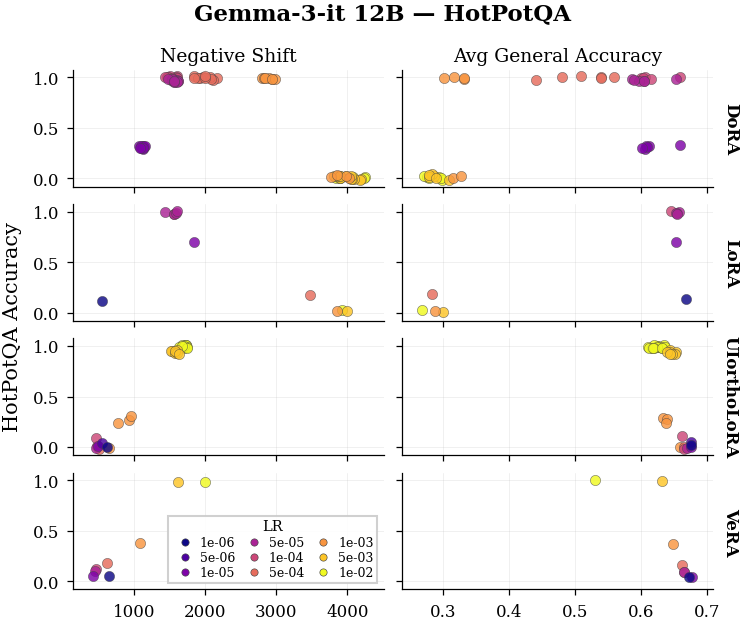

In [117]:
plot_all_configs(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpot', 'negative_shift_score', save_path="./graphs/gemma-hotpot-lr")

In [118]:
stop

NameError: name 'stop' is not defined

Saved: ./graphs/gemma-hotpot-size/dora_gemma-12b_hotpot_by_size.png


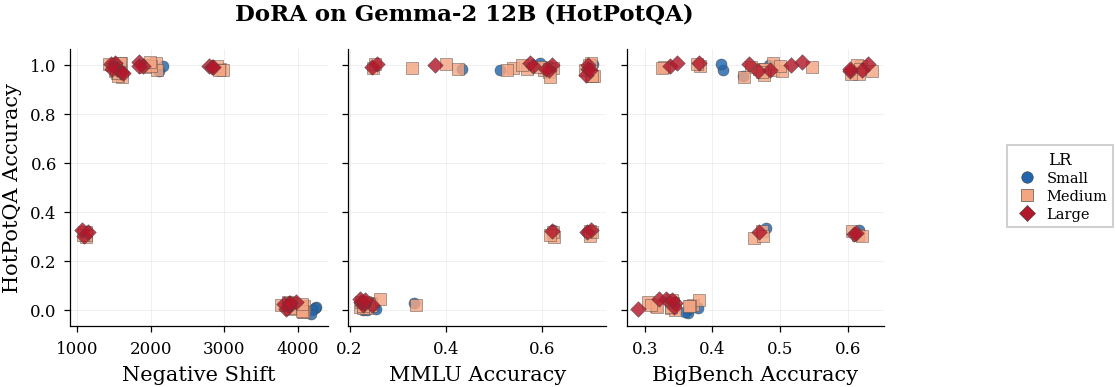

Saved: ./graphs/gemma-hotpot-size/lora_gemma-12b_hotpot_by_size.png


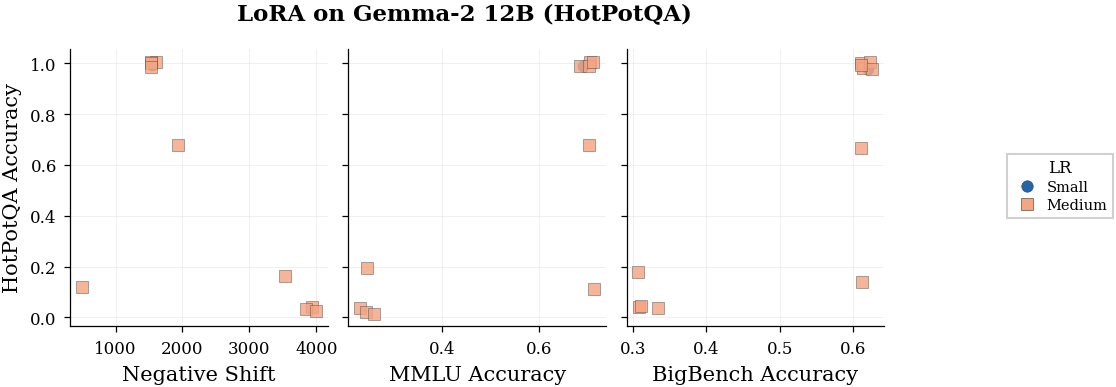

Saved: ./graphs/gemma-hotpot-size/uiortholora_gemma-12b_hotpot_by_size.png


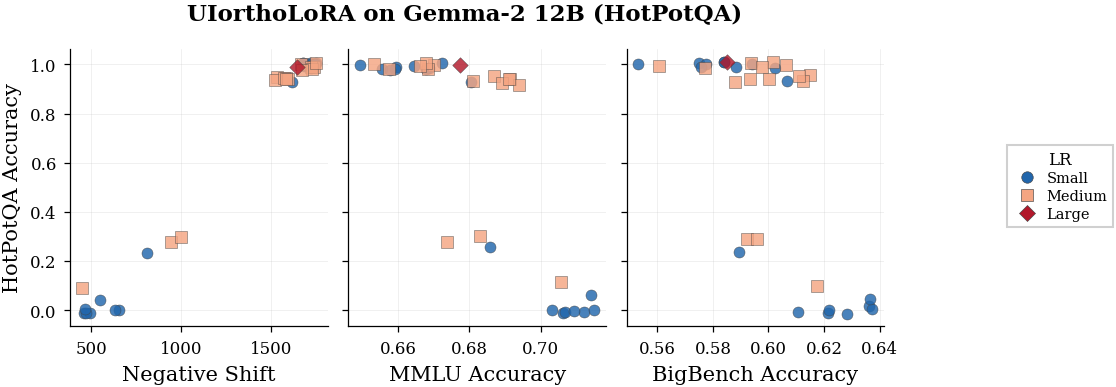

Saved: ./graphs/gemma-hotpot-size/vera_gemma-12b_hotpot_by_size.png


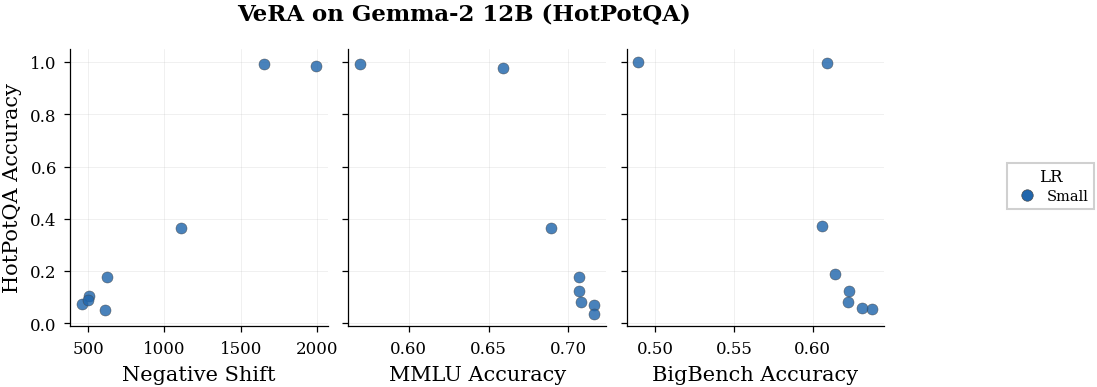

In [ ]:
plot_all_configs_by_size(gemma_hotpot_mmlu, gemma_hotpot_bb, 'gemma-12b', 'hotpot', 'negative_shift_score', save_path="./graphs/gemma-hotpot-size")